## Following along with Andrej Karpathy's lecture on "micrograd"
Andrej's video: https://www.youtube.com/watch?v=VMj-3S1tku0
Andrej's github: https://github.com/karpathy/micrograd

Current progress: 1:39:53, next step is a small pytorch example verifying our results so far

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline 

In [17]:
# start building out the Value class/object
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children) # set() unordered collection of unique elements
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data,
                    (self, other), # keep record of children
                    '+'            # keep track of the operator that created the Value object
        )

        def _backward():
            # for addition we "copy" the parent grad to the child
            # A      + B      = C
            # parent + parent = child
            # 
            # both local derivs are 1.0: dC/dA = 1, dC/dB = 1
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data,
                    (self, other), # keep record of children
                    '*'            # keep track of the operator that created the Value object
        )

        def _backward():
            # for multiplication we mutliply by the child
            # A      * B      = C
            # parent * parent = child
            # 
            # local derivs are: dC/dA = B, dC/dB = A
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def __pow__(self, other): # self**other
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            # for multiplication we mutliply by the child
            # A      ^ B      = C
            # parent ^ parent = child
            # 
            # local derivs are: dC/dA = B*A**(B-1), dC/dB = logA A**B
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += (other * self.data**(other-1.0)) * out.grad
            #other.grad += self.data * out.grad

        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1.0
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # for tanh
            # B     = tanh(A)
            # child = tanh(parent)
            # 
            # child deriv wrt to input(s): dB/dA = 1 - tanh(A)**2 = 1 - B**2
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += (1 - t**2) * out.grad
            #other.grad = ...  no "other" for this operator

        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            # for exp
            # B     = exp(A)
            # child = exp(parent)
            # 
            # child deriv wrt to input(s): dB/dA = exp(A) = B
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += out.data * out.grad
            #other.grad = ...  no "other" for this operator

        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo): # note to start at the output node o, we need to reverse topo
            # print('_backward() for ', node.label)
            node._backward()

a = Value(2.0)
a - 2

Value(data=0.0)

In [3]:
# Visualization code, plot a graph showing how a value was created
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad, ), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [4]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1*w1 + x2*w2'
n = x1w1_x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

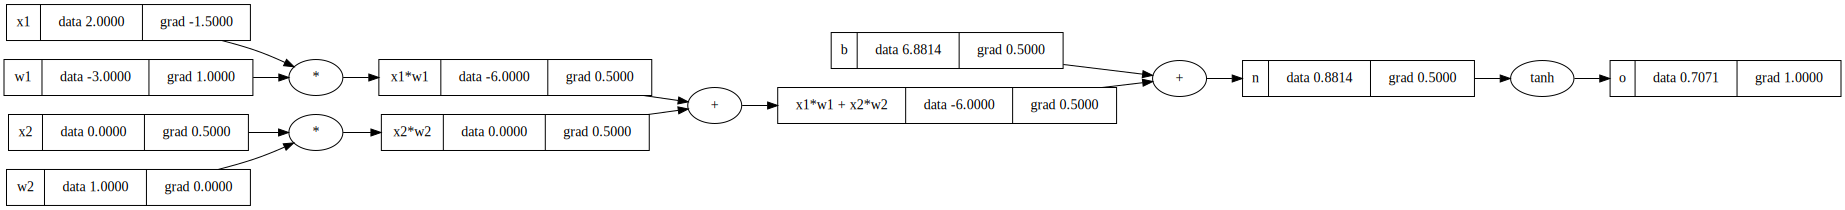

In [5]:
draw_dot(o)

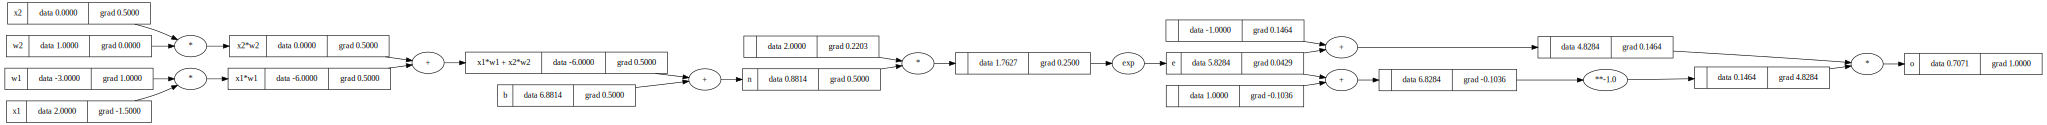

In [6]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1*w1 + x2*w2'
n = x1w1_x2w2 + b; n.label = 'n'
#============================
#o = n.tanh()
e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1)
o.label = 'o'
#============================
o.backward()
draw_dot(o)

In [34]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        #print(list(wi*xi for wi, xi in zip(self.w, x)))
        #print(self.b)
        activation = sum( (wi*xi for wi, xi in zip(self.w, x)), self.b )
        out = activation.tanh()
        return out

class Layer:
    def __init__(self, nin, nout):
        # a list of <nout> Neurons each having <nin> inputs
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

class MLP:
    def __init__(self, nin, nouts):
        # a multi layer perceptron
        #   <nin> inputs, connected to:
        #   nouts[0] neurons, conneced to:
        #   nouts[1] neurons, ...
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# MLP example, e.g.:
# 3 inputs, connected to
# layer of 4 neuron(s), connected to
# 2nd layer of 4 neuron(s), connected to
# layer of 1 neuron(s) (output layer)
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.9319182243102321)

In [37]:
#draw_dot(n(x))

In [38]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

# target y values: "a binary classifier", either +1 or -1
ys = [1.0, -1.0, -1.0, 1.0]

# untrained prediction of y's
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9319182243102321),
 Value(data=0.37814671027900104),
 Value(data=0.7645026332970514),
 Value(data=0.8967793528516846)]

In [39]:
[(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=0.004635128181071874),
 Value(data=1.8992883550528328),
 Value(data=3.1134695429122288),
 Value(data=0.010654501997717024)]